In [2]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent, save_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

# Configuration
env_name = "antmaze-large-navigate-singletask-task1-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 50

# Agent paths and epochs
a5_jacb_reg_e5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_173407_utd-ratio1"
# a3_jacb_reg_e5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_174856_utd-ratio1"
a3_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_195824_utd-ratio1"
a3_hess_reg_e5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250905_164434_utd-ratio1"
a3_jacb_reg_e6_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_200256_utd-ratio1"
a5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_115351_utd-ratio1"

a3_val_reg_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250908_162315_utd-ratio1"
# agent_path=a5_jacb_reg_e5_agent_path
agent_path=a3_agent_path
restore_epoch=1000000

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

# Load FQL agent configuration and create agent
from agents.iql import get_config as get_iql_config
iql_config = get_iql_config()

iql_agent_class = agents[iql_config['agent_name']]
iql_agent = iql_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    iql_config,
)

# Restore trained models
if agent_path and restore_epoch:
    iql_agent = restore_agent(iql_agent, agent_path, restore_epoch)
    print(f"IQL agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_195824_utd-ratio1/params_1000000.pkl
IQL agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_195824_utd-ratio1 at epoch 1000000
Models loaded successfully!


In [2]:
# Generate trajectories for both agents
print("Generating trajectories for IQL agent...")
iql_eval_info, iql_trajs, iql_renders = evaluate(
    agent=iql_agent,
    env=eval_env,
    config=iql_config,
    num_eval_episodes=eval_episodes,
    num_video_episodes=0,  # Skip video rendering for now
)

print(iql_eval_info)

Generating trajectories for IQL agent...


100%|██████████| 50/50 [00:34<00:00,  1.44it/s]

defaultdict(<class 'list'>, {'xy': 11.783783453659291, 'prev_qpos': 1.6392108283620759, 'prev_qvel': -0.04047179188331189, 'qpos': 1.636157924509374, 'qvel': -0.03321762716812929, 'success': 0.82, 'total.timesteps': 18176.98, 'episode.final_reward': -0.18, 'episode.return': -709.44, 'episode.length': 710.26, 'episode.duration': 0.6942195224761963})


In [3]:
# Get failure cases
success_trajs = []
failed_trajs = []
for i in range(eval_episodes):
    if not iql_trajs[i]['info'][-1]['success']:
        failed_trajs.append(iql_trajs[i])
    else:
        success_trajs.append(iql_trajs[i])

In [135]:
# Define actor and critic functions for easier access
def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

def iql_critic_fn(observations, actions):
    """Get Q-values from the IQL critic."""
    return iql_agent.network.select('critic')(observations, actions=actions)

iql_actor_fn = supply_rng(iql_agent.sample_actions, rng=jax.random.PRNGKey(0))
iql_reg_actor_fn = supply_rng(iql_agent_reg.sample_actions, rng=jax.random.PRNGKey(0))

print("Actor and critic functions defined!")


Actor and critic functions defined!


In [15]:
import jax.numpy as jnp

# Sample batch from training dataset
batch_size = 10000

# plot in the restricted region
x_min, x_max = 18, 40
y_min, y_max = 0, 26
samples = train_dataset.sample(batch_size*100)

batch_states = samples['observations']
batch_pos = batch_states[:, :2]
valid_idx = (batch_pos[:, 0] >= x_min) & (batch_pos[:, 0] <= x_max) & (batch_pos[:, 1] >= y_min) & (batch_pos[:, 1] <= y_max)
batch_states = batch_states[valid_idx]
batch_actions = samples['actions'][valid_idx]

print(jnp.array(batch_states).shape)

(509926, 29)


In [140]:
def iql_reg_critic_fn(observations, actions):
    """Get Q-values from the IQL critic."""
    return iql_agent_reg.network.select('critic')(observations, actions=actions)

def compute_q_gradients_reg(states, actions):
    def q_output(state, action):
        # Get Q-value for a single state-action pair
        q_values = iql_reg_critic_fn(state[None, :], action[None, :])
        # Return mean Q-value if there are multiple critics (IQL typically has 2 critics)
        return jnp.mean(q_values)
    
    # Compute gradient of Q w.r.t. state for each state-action pair
    grad_fn = jax.vmap(jax.grad(q_output, argnums=0))  # Gradient w.r.t. state (argnums=0)

    # Compute by batch (do not flatten out)
    batch_size = 10000
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        batch_actions = actions[i:batch_end]
        gradients = grad_fn(batch_states, batch_actions)
        if i == 0:
            all_gradients = gradients
        else:
            all_gradients = np.concatenate([all_gradients, gradients], axis=0)
    return all_gradients

def get_policy_actions_reg(states):

    batch_size = 256
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        actions = iql_reg_actor_fn(batch_states)
        if i == 0:
            all_actions = actions
        else:
            all_actions = np.concatenate([all_actions, actions], axis=0)
    return all_actions

Computing Q function gradients...


  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:02<00:00,  7.32it/s]


(201070, 29)


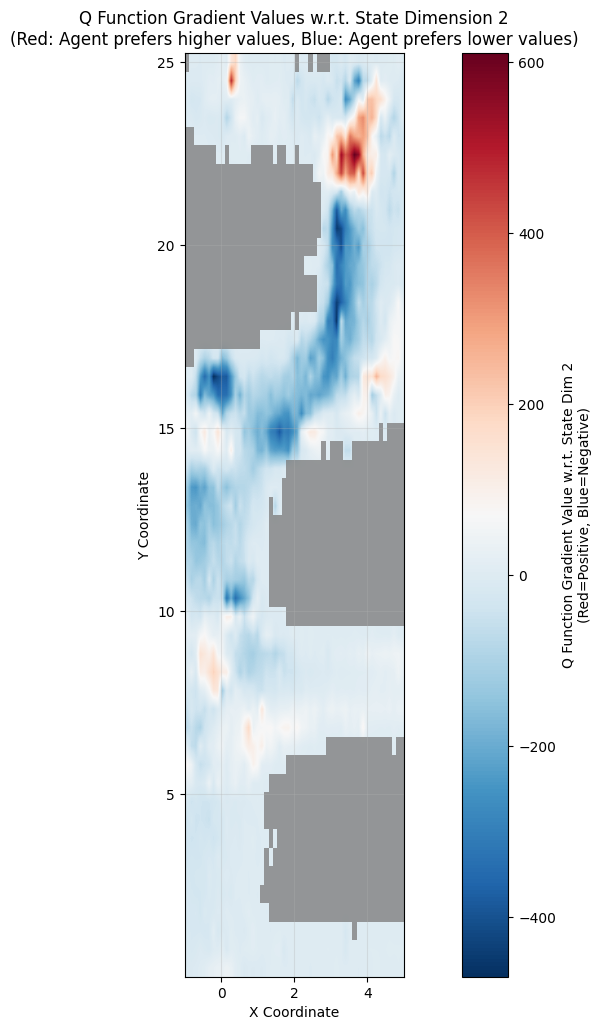

In [138]:
# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

# Set the state dimension to analyze (0 for x, 1 for y, etc.)

# Define function to compute Q function gradients with respect to state dimensions
def compute_q_gradients(states, actions):
    def q_output(state, action):
        # Get Q-value for a single state-action pair
        q_values = iql_critic_fn(state[None, :], action[None, :])
        # Return mean Q-value if there are multiple critics (IQL typically has 2 critics)
        return jnp.mean(q_values)
    
    # Compute gradient of Q w.r.t. state for each state-action pair
    grad_fn = jax.vmap(jax.grad(q_output, argnums=0))  # Gradient w.r.t. state (argnums=0)

    # Compute by batch (do not flatten out)
    batch_size = 10000
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        batch_actions = actions[i:batch_end]
        gradients = grad_fn(batch_states, batch_actions)
        if i == 0:
            all_gradients = gradients
        else:
            all_gradients = np.concatenate([all_gradients, gradients], axis=0)
    return all_gradients

# Get corresponding actions for the states (using the policy)
def get_policy_actions(states):

    batch_size = 256
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        actions = iql_actor_fn(batch_states)
        if i == 0:
            all_actions = actions
        else:
            all_actions = np.concatenate([all_actions, actions], axis=0)
    return all_actions

print("Computing Q function gradients...")
q_gradients = compute_q_gradients(batch_states_jax, batch_actions)
print(q_gradients.shape)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

state_dim_to_analyze = 2 # Change this to analyze different state dimensions

# Extract gradients for the specified state dimension
# q_gradients shape: (batch_size, state_dim)
grad_wrt_state_dim = np.array(q_gradients[:, state_dim_to_analyze])  # Q gradient w.r.t. specified state dim

# Use gradient values directly (with sign) instead of magnitude
grad_values = grad_wrt_state_dim  # Keep the sign for meaningful interpretation

# Also compute magnitudes for sorting (to find most sensitive states)
grad_magnitudes = np.abs(grad_wrt_state_dim)

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient VALUES (with sign)
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_values)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap with diverging colormap (red=positive, blue=negative)
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='RdBu_r', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Q Function Gradient Value w.r.t. State Dim {state_dim_to_analyze}\n(Red=Positive, Blue=Negative)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Q Function Gradient Values w.r.t. State Dimension {state_dim_to_analyze}\n(Red: Agent prefers higher values, Blue: Agent prefers lower values)')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top states with highest Q gradient magnitudes
top_indices = sorted_indices[:100]
top_states = batch_states_jax[top_indices]

# Get actions for these top states
top_actions = batch_actions[top_indices]

hist_counts, _, _ = np.histogram2d(x_coords, y_coords, bins=50)
zero_mask = hist_counts.T == 0

# Create a grey overlay for zero-count areas
grey_overlay = np.ones_like(hist.T) * 0.5  # Grey value
grey_overlay = np.ma.masked_where(~zero_mask, grey_overlay)

# Apply grey overlay to areas with zero states
plt.imshow(grey_overlay, extent=extent, origin='lower', 
          cmap='gray', alpha=0.8, vmin=0, vmax=1)

plt.show()


Getting policy actions...


  0%|          | 0/786 [00:00<?, ?it/s]

100%|██████████| 786/786 [00:01<00:00, 491.08it/s] 


Computing Q function gradients...


100%|██████████| 21/21 [00:02<00:00,  7.38it/s]


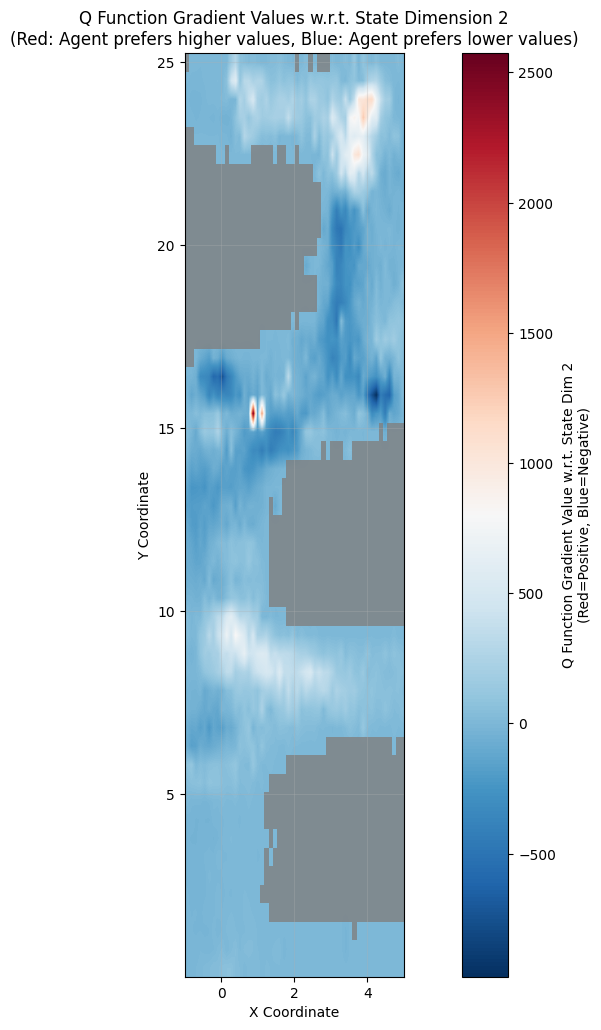

In [139]:
# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

# Set the state dimension to analyze (0 for x, 1 for y, etc.)

print("Getting policy actions...")
policy_actions = get_policy_actions(batch_states_jax)

print("Computing Q function gradients...")
q_gradients = compute_q_gradients(batch_states_jax, policy_actions)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

# Extract gradients for the specified state dimension
# q_gradients shape: (batch_size, state_dim)
grad_wrt_state_dim = np.array(q_gradients[:, state_dim_to_analyze])  # Q gradient w.r.t. specified state dim

# Use gradient values directly (with sign) instead of magnitude
grad_values = grad_wrt_state_dim  # Keep the sign for meaningful interpretation

# Also compute magnitudes for sorting (to find most sensitive states)
grad_magnitudes = np.abs(grad_wrt_state_dim)

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient VALUES (with sign)
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_values)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap with diverging colormap (red=positive, blue=negative)
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='RdBu_r', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Q Function Gradient Value w.r.t. State Dim {state_dim_to_analyze}\n(Red=Positive, Blue=Negative)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Q Function Gradient Values w.r.t. State Dimension {state_dim_to_analyze}\n(Red: Agent prefers higher values, Blue: Agent prefers lower values)')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top states with highest Q gradient magnitudes
top_indices = sorted_indices[:100]
top_states = batch_states_jax[top_indices]

# Get actions for these top states
top_actions = batch_actions[top_indices]

hist_counts, _, _ = np.histogram2d(x_coords, y_coords, bins=50)
zero_mask = hist_counts.T == 0

# Create a grey overlay for zero-count areas
grey_overlay = np.ones_like(hist.T) * 0.5  # Grey value
grey_overlay = np.ma.masked_where(~zero_mask, grey_overlay)

# Apply grey overlay to areas with zero states
plt.imshow(grey_overlay, extent=extent, origin='lower', 
          cmap='gray', alpha=0.8, vmin=0, vmax=1)

plt.show()

Getting policy actions...


100%|██████████| 786/786 [00:01<00:00, 565.91it/s] 


Computing Q function gradients...


100%|██████████| 21/21 [00:02<00:00,  7.51it/s]


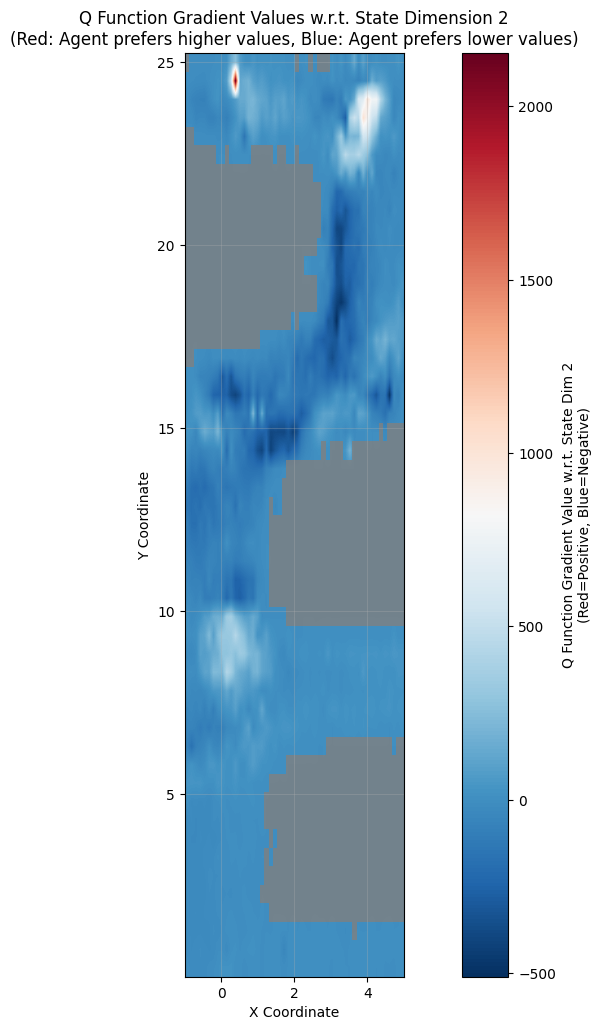

In [141]:
# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

# Set the state dimension to analyze (0 for x, 1 for y, etc.)

print("Getting policy actions...")
policy_actions = get_policy_actions_reg(batch_states_jax)

print("Computing Q function gradients...")
q_gradients = compute_q_gradients_reg(batch_states_jax, policy_actions)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

# Extract gradients for the specified state dimension
# q_gradients shape: (batch_size, state_dim)
grad_wrt_state_dim = np.array(q_gradients[:, state_dim_to_analyze])  # Q gradient w.r.t. specified state dim

# Use gradient values directly (with sign) instead of magnitude
grad_values = grad_wrt_state_dim  # Keep the sign for meaningful interpretation

# Also compute magnitudes for sorting (to find most sensitive states)
grad_magnitudes = np.abs(grad_wrt_state_dim)

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient VALUES (with sign)
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_values)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap with diverging colormap (red=positive, blue=negative)
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='RdBu_r', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Q Function Gradient Value w.r.t. State Dim {state_dim_to_analyze}\n(Red=Positive, Blue=Negative)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Q Function Gradient Values w.r.t. State Dimension {state_dim_to_analyze}\n(Red: Agent prefers higher values, Blue: Agent prefers lower values)')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top states with highest Q gradient magnitudes
top_indices = sorted_indices[:100]
top_states = batch_states_jax[top_indices]

# Get actions for these top states
top_actions = batch_actions[top_indices]

hist_counts, _, _ = np.histogram2d(x_coords, y_coords, bins=50)
zero_mask = hist_counts.T == 0

# Create a grey overlay for zero-count areas
grey_overlay = np.ones_like(hist.T) * 0.5  # Grey value
grey_overlay = np.ma.masked_where(~zero_mask, grey_overlay)

# Apply grey overlay to areas with zero states
plt.imshow(grey_overlay, extent=extent, origin='lower', 
          cmap='gray', alpha=0.8, vmin=0, vmax=1)

plt.show()

Getting policy actions...
Computing Q function gradients...


100%|██████████| 48/48 [00:06<00:00,  7.29it/s]


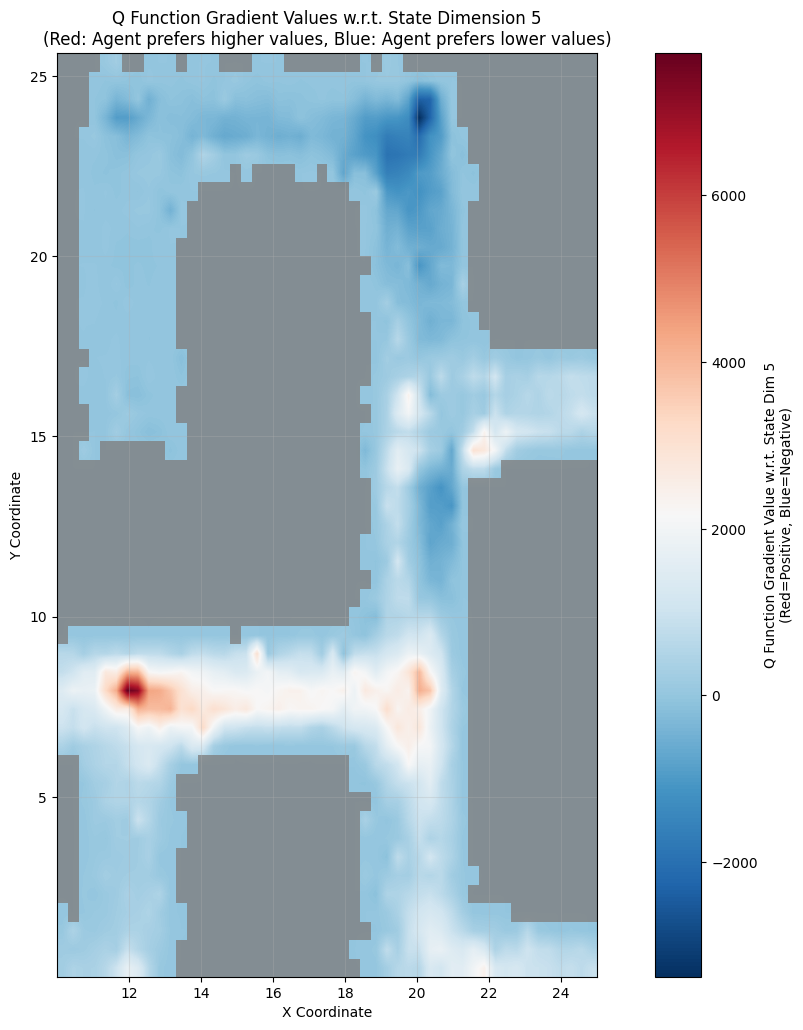

In [130]:
# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

print("Getting policy actions...")
perturbation_range=0.1
pertrubed_actions = policy_actions + np.random.normal(0, perturbation_range, policy_actions.shape)

print("Computing Q function gradients...")
q_gradients = compute_q_gradients(batch_states_jax, pertrubed_actions)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

# Extract gradients for the specified state dimension
# q_gradients shape: (batch_size, state_dim)
grad_wrt_state_dim = np.array(q_gradients[:, state_dim_to_analyze])  # Q gradient w.r.t. specified state dim

# Use gradient values directly (with sign) instead of magnitude
grad_values = grad_wrt_state_dim  # Keep the sign for meaningful interpretation

# Also compute magnitudes for sorting (to find most sensitive states)
grad_magnitudes = np.abs(grad_wrt_state_dim)

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient VALUES (with sign)
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_values)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap with diverging colormap (red=positive, blue=negative)
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='RdBu_r', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Q Function Gradient Value w.r.t. State Dim {state_dim_to_analyze}\n(Red=Positive, Blue=Negative)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Q Function Gradient Values w.r.t. State Dimension {state_dim_to_analyze}\n(Red: Agent prefers higher values, Blue: Agent prefers lower values)')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top states with highest Q gradient magnitudes
top_indices = sorted_indices[:100]
top_states = batch_states_jax[top_indices]

# Get actions for these top states
top_actions = batch_actions[top_indices]

hist_counts, _, _ = np.histogram2d(x_coords, y_coords, bins=50)
zero_mask = hist_counts.T == 0

# Create a grey overlay for zero-count areas
grey_overlay = np.ones_like(hist.T) * 0.5  # Grey value
grey_overlay = np.ma.masked_where(~zero_mask, grey_overlay)

# Apply grey overlay to areas with zero states
plt.imshow(grey_overlay, extent=extent, origin='lower', 
          cmap='gray', alpha=0.8, vmin=0, vmax=1)

plt.show()


### Flow-matching policy

In [3]:

# Agent paths and epochs
fbrac_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250908_154227_utd-ratio1"
fbrac_reg_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd002_20250908_200922_utd-ratio1"
fbrac_reg_weighted_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd000_20250908_201030_utd-ratio1"

# agent_path=a5_jacb_reg_e5_agent_path
reg_agent_path=fbrac_reg_weighted_path
agent_path=fbrac_path
restore_epoch=1000000

# double check the agent seed
def extract_seed(agent_path):
    # extract sd{:3}_ from agent_path
    return int(agent_path.split("_sd")[1].split("_")[0])
agent_seed = extract_seed(agent_path)

env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

from agents.fbrac import get_config as get_fbrac_config
from agents.fql import get_config as get_fql_config
fbrac_config = get_fbrac_config()
fql_config = get_fql_config()

fbrac_agent_class = agents[fbrac_config['agent_name']]
fbrac_agent_reg = fbrac_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fbrac_config,
)

fbrac_agent = fbrac_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fbrac_config,
)

# Restore trained models
if reg_agent_path and restore_epoch:
    fbrac_agent_reg = restore_agent(fbrac_agent_reg, reg_agent_path, restore_epoch)
    print(f"FBRAC agent restored from {reg_agent_path} at epoch {restore_epoch}")

if agent_path and restore_epoch:
    fbrac_agent = restore_agent(fbrac_agent, agent_path, restore_epoch)
    print(f"FBRAC agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")

Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd000_20250908_201030_utd-ratio1/params_1000000.pkl
FBRAC agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd000_20250908_201030_utd-ratio1 at epoch 1000000
Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250908_154227_utd-ratio1/params_1000000.pkl
FBRAC agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250908_154227_utd-ratio1 at epoch 1000000
Models loaded successfully!


Computing Q function gradients...


  0%|          | 0/51 [00:00<?, ?it/s]

100%|██████████| 51/51 [00:06<00:00,  7.46it/s]


(509926, 29)


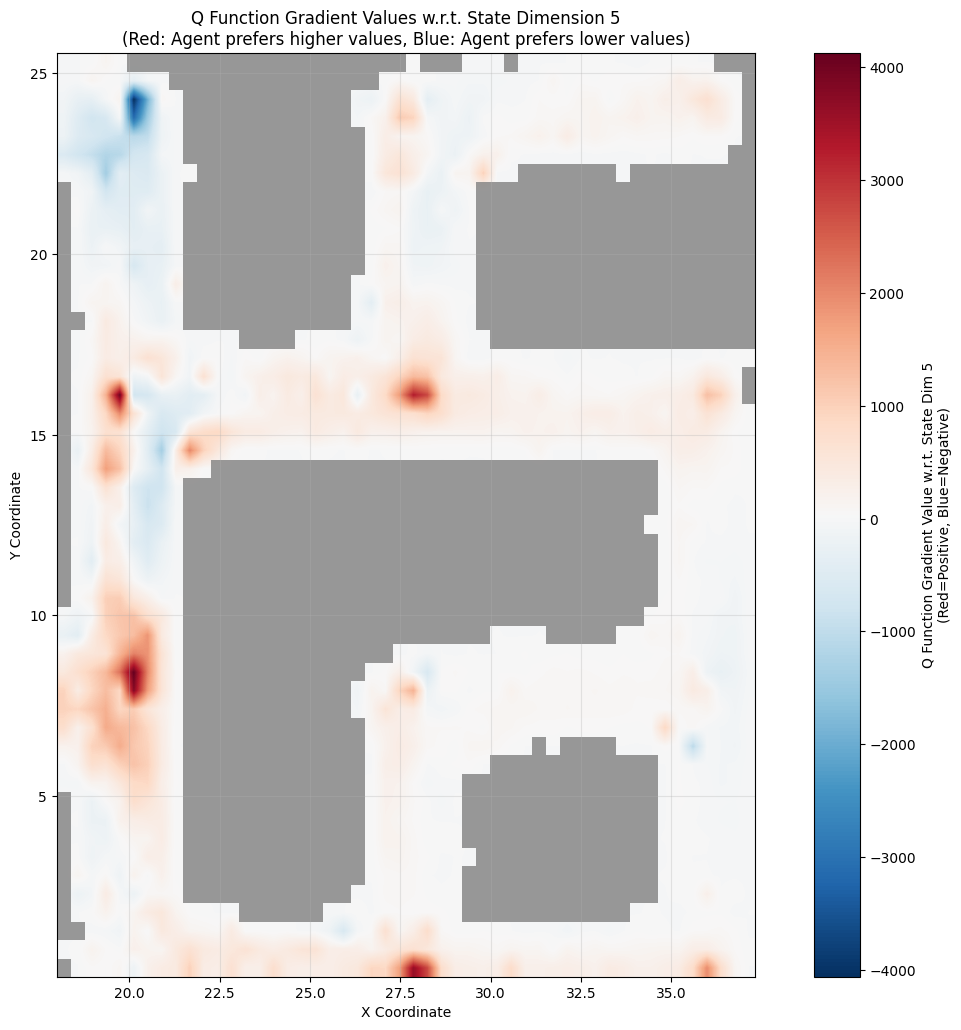

In [19]:
import jax
import jax.numpy as jnp

def fbrac_critic_fn(states, actions):
    return fbrac_agent.network.select('critic')(states, actions)

def fbrac_actor_fn(states):
    return fbrac_agent.sample_actions(states)

# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

# Set the state dimension to analyze (0 for x, 1 for y, etc.)

# Define function to compute Q function gradients with respect to state dimensions
def compute_q_gradients(states, actions):
    def q_output(state, action):
        # Get Q-value for a single state-action pair
        q_values = fbrac_critic_fn(state[None, :], action[None, :])
        # Return mean Q-value if there are multiple critics (IQL typically has 2 critics)
        return jnp.mean(q_values)
    
    # Compute gradient of Q w.r.t. state for each state-action pair
    grad_fn = jax.vmap(jax.grad(q_output, argnums=0))  # Gradient w.r.t. state (argnums=0)

    # Compute by batch (do not flatten out)
    batch_size = 10000
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        batch_actions = actions[i:batch_end]
        gradients = grad_fn(batch_states, batch_actions)
        if i == 0:
            all_gradients = gradients
        else:
            all_gradients = np.concatenate([all_gradients, gradients], axis=0)
    return all_gradients

# Get corresponding actions for the states (using the policy)
def get_policy_actions(states):

    batch_size = 256
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        actions = fbrac_actor_fn(batch_states)
        if i == 0:
            all_actions = actions
        else:
            all_actions = np.concatenate([all_actions, actions], axis=0)
    return all_actions

print("Computing Q function gradients...")
q_gradients = compute_q_gradients(batch_states_jax, batch_actions)
print(q_gradients.shape)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

state_dim_to_analyze = 5 # Change this to analyze different state dimensions

# Extract gradients for the specified state dimension
# q_gradients shape: (batch_size, state_dim)
grad_wrt_state_dim = np.array(q_gradients[:, state_dim_to_analyze])  # Q gradient w.r.t. specified state dim

# Use gradient values directly (with sign) instead of magnitude
grad_values = grad_wrt_state_dim  # Keep the sign for meaningful interpretation

# Also compute magnitudes for sorting (to find most sensitive states)
grad_magnitudes = np.abs(grad_wrt_state_dim)

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient VALUES (with sign)
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_values)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap with diverging colormap (red=positive, blue=negative)
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='RdBu_r', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Q Function Gradient Value w.r.t. State Dim {state_dim_to_analyze}\n(Red=Positive, Blue=Negative)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Q Function Gradient Values w.r.t. State Dimension {state_dim_to_analyze}\n(Red: Agent prefers higher values, Blue: Agent prefers lower values)')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top states with highest Q gradient magnitudes
top_indices = sorted_indices[:100]
top_states = batch_states_jax[top_indices]

# Get actions for these top states
top_actions = batch_actions[top_indices]

hist_counts, _, _ = np.histogram2d(x_coords, y_coords, bins=50)
zero_mask = hist_counts.T == 0

# Create a grey overlay for zero-count areas
grey_overlay = np.ones_like(hist.T) * 0.5  # Grey value
grey_overlay = np.ma.masked_where(~zero_mask, grey_overlay)

# Apply grey overlay to areas with zero states
plt.imshow(grey_overlay, extent=extent, origin='lower', 
          cmap='gray', alpha=0.8, vmin=0, vmax=1)

plt.show()

Computing Q function gradients...


100%|██████████| 51/51 [00:06<00:00,  7.39it/s]


(509926, 29)


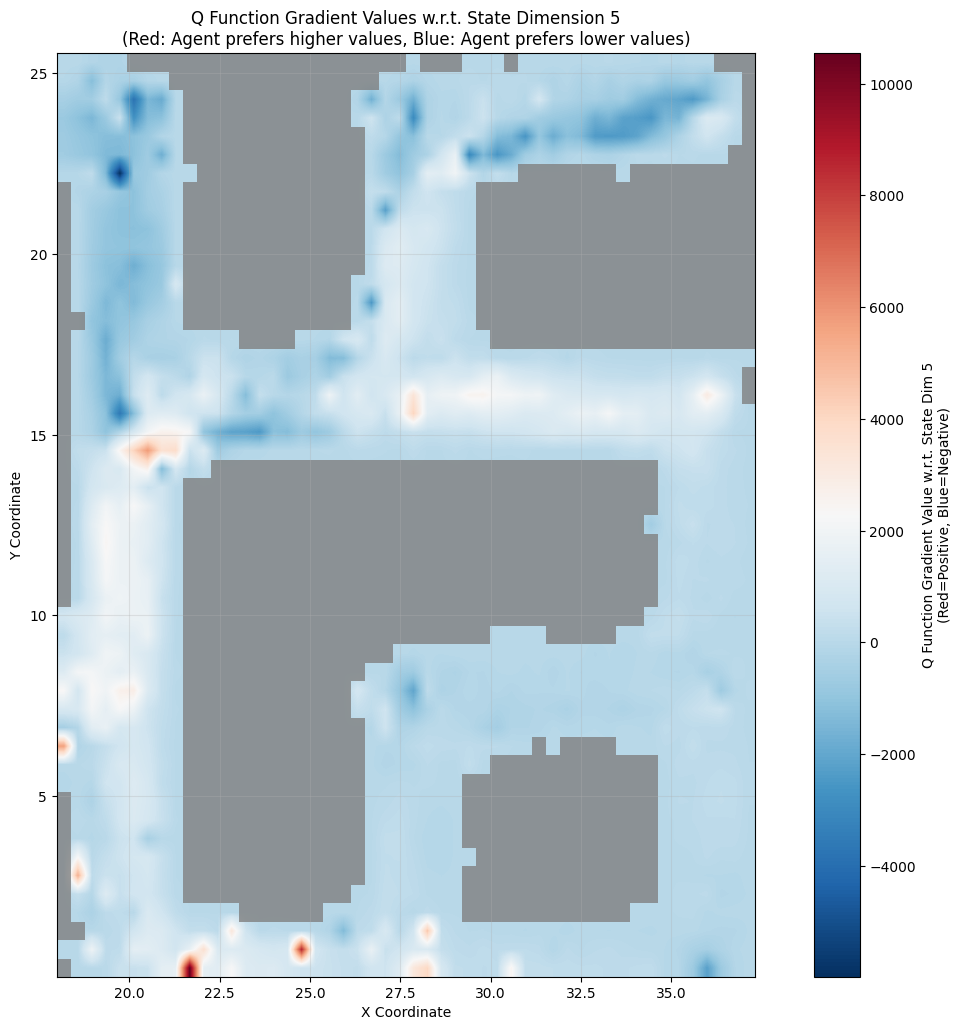

In [20]:
def fbrac_reg_critic_fn(states, actions):
    return fbrac_agent_reg.network.select('critic')(states, actions)

def fbrac_reg_actor_fn(states):
    return fbrac_agent_reg.sample_actions(states)

# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

def compute_q_gradients_reg(states, actions):
    def q_output(state, action):
        # Get Q-value for a single state-action pair
        q_values = fbrac_reg_critic_fn(state[None, :], action[None, :])
        # Return mean Q-value if there are multiple critics (IQL typically has 2 critics)
        return jnp.mean(q_values)
    
    # Compute gradient of Q w.r.t. state for each state-action pair
    grad_fn = jax.vmap(jax.grad(q_output, argnums=0))  # Gradient w.r.t. state (argnums=0)

    # Compute by batch (do not flatten out)
    batch_size = 10000
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        batch_actions = actions[i:batch_end]
        gradients = grad_fn(batch_states, batch_actions)
        if i == 0:
            all_gradients = gradients
        else:
            all_gradients = np.concatenate([all_gradients, gradients], axis=0)
    return all_gradients

# Get corresponding actions for the states (using the policy)
def get_policy_actions_fbrac_reg(states):

    batch_size = 256
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        actions = fbrac_reg_actor_fn(batch_states)
        if i == 0:
            all_actions = actions
        else:
            all_actions = np.concatenate([all_actions, actions], axis=0)
    return all_actions

print("Computing Q function gradients...")
q_gradients = compute_q_gradients_reg(batch_states_jax, batch_actions)
print(q_gradients.shape)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

state_dim_to_analyze = 5 # Change this to analyze different state dimensions

# Extract gradients for the specified state dimension
# q_gradients shape: (batch_size, state_dim)
grad_wrt_state_dim = np.array(q_gradients[:, state_dim_to_analyze])  # Q gradient w.r.t. specified state dim

# Use gradient values directly (with sign) instead of magnitude
grad_values = grad_wrt_state_dim  # Keep the sign for meaningful interpretation

# Also compute magnitudes for sorting (to find most sensitive states)
grad_magnitudes = np.abs(grad_wrt_state_dim)

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient VALUES (with sign)
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_values)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap with diverging colormap (red=positive, blue=negative)
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='RdBu_r', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Q Function Gradient Value w.r.t. State Dim {state_dim_to_analyze}\n(Red=Positive, Blue=Negative)')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Q Function Gradient Values w.r.t. State Dimension {state_dim_to_analyze}\n(Red: Agent prefers higher values, Blue: Agent prefers lower values)')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top states with highest Q gradient magnitudes
top_indices = sorted_indices[:100]
top_states = batch_states_jax[top_indices]

# Get actions for these top states
top_actions = batch_actions[top_indices]

hist_counts, _, _ = np.histogram2d(x_coords, y_coords, bins=50)
zero_mask = hist_counts.T == 0

# Create a grey overlay for zero-count areas
grey_overlay = np.ones_like(hist.T) * 0.5  # Grey value
grey_overlay = np.ma.masked_where(~zero_mask, grey_overlay)

# Apply grey overlay to areas with zero states
plt.imshow(grey_overlay, extent=extent, origin='lower', 
          cmap='gray', alpha=0.8, vmin=0, vmax=1)

plt.show()

In [121]:
# Load FQL humanoid agent

import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent, save_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

# Configuration
env_name = "humanoidmaze-medium-navigate-singletask-task2-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 50

fql_humanoidmaze_medium_reg_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_humanoidmaze-medium-navigate-singletask-task2-v0_sd000_20250909_191200_utd-ratio1"
fql_humanoidmaze_medium_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_humanoidmaze-medium-navigate-singletask-task2-v0_sd000_20250909_193638_utd-ratio1"

agent_path=fql_humanoidmaze_medium_path
restore_epoch=1000000

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

# Load FQL agent configuration and create agent
from agents.fql import get_config as get_fql_config
fql_config = get_fql_config()

fql_agent_class = agents[fql_config['agent_name']]
fql_agent = fql_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fql_config,
)

# Restore trained models
if agent_path and restore_epoch:
    fql_agent = restore_agent(fql_agent, agent_path, restore_epoch)
    print(f"FQL agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv
Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_humanoidmaze-medium-navigate-singletask-task2-v0_sd000_20250909_193638_utd-ratio1/params_1000000.pkl
FQL agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_humanoidmaze-medium-navigate-singletask-task2-v0_sd000_20250909_193638_utd-ratio1 at epoch 1000000
Models loaded successfully!


In [26]:
search_space = train_dataset.sample(100000)

num_actions = 10000
batch = train_dataset.sample(num_actions)
actions = batch['actions']
actions.shape

(10000, 21)

In [150]:
def critic_fn(agent, states, actions, batch_size=256, q_agg='min'):
    q_values = []
    for i in tqdm(range(0, len(states), batch_size)):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        batch_actions = actions[i:batch_end]

        curr_vals = agent.network.select('critic')(batch_states, batch_actions)
        if q_agg == 'min':
            curr_vals = np.min(curr_vals, axis=0)
        else:
            curr_vals = np.mean(curr_vals, axis=0)
        q_values.extend(curr_vals)
    return np.array(q_values)

def sample_state(x, y, batch):
    states = batch['observations']
    actions = batch['actions']

    # Get the states near the given x, y
    idx = (states[:, 0] >= x - 0.1) & (states[:, 0] <= x + 0.1) & (states[:, 1] >= y - 0.1) & (states[:, 1] <= y + 0.1)
    states_near = states[idx]
    dataset_actions = actions[idx]
    return states_near, dataset_actions

In [157]:
x, y = 12, 8
target_states, dataset_actions = sample_state(x, y, search_space)
target_idx = np.random.choice(np.arange(target_states.shape[0]))

target_states = target_states[target_idx].reshape(1, -1).repeat(num_actions, axis=0)
dataset_action = dataset_actions[target_idx]

Generating sample data for demonstration...
Plotting Q-value trend for action dimension 12...


100%|██████████| 40/40 [00:02<00:00, 13.51it/s]
/tmp/ipykernel_3696325/1565409204.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('action_bin').agg(


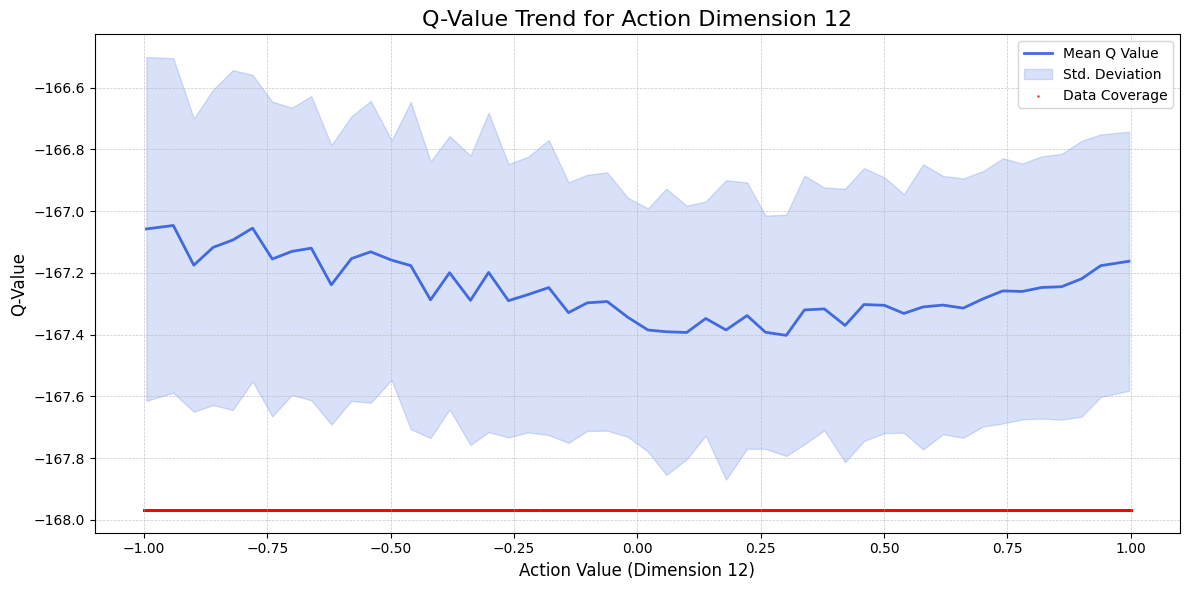

In [122]:
import pandas as pd

def plot_q_value_trend(actions, q_values, target_action_dim, num_bins=50):
    """
    Plots the average Q-value as a continuous line by binning action values.

    This provides a clear view of the central trend and the variance (confidence)
    of the Q-function with respect to a specific action dimension.

    Args:
        actions (np.ndarray): A 2D array of actions, shape (num_samples, action_dim).
        q_values (np.ndarray): A 1D array of corresponding Q-values.
        target_action_dim (int): The index of the action dimension to plot.
        num_bins (int): The number of bins to group the action values into.
    """
    # Extract the target action dimension from the actions array
    action_values = actions[:, target_action_dim]

    # Use a pandas DataFrame to easily bin and aggregate the data
    df = pd.DataFrame({
        'action_value': action_values,
        'q_value': q_values
    })

    # Create discrete bins from the continuous action values
    df['action_bin'] = pd.cut(df['action_value'], bins=num_bins)

    # For each bin, calculate the statistics:
    # - The center of the bin (mean of action values in it)
    # - The average Q-value in the bin
    # - The standard deviation of Q-values in the bin
    binned_stats = df.groupby('action_bin').agg(
        action_mean=('action_value', 'mean'),
        q_mean=('q_value', 'mean'),
        q_std=('q_value', 'std')
    ).dropna() # Drop any bins that might be empty

    # --- Plotting ---
    plt.figure(figsize=(12, 6))

    # Plot the main trend line connecting the mean Q-values of each bin
    plt.plot(binned_stats['action_mean'], binned_stats['q_mean'],
             color='royalblue', linewidth=2, label='Mean Q Value')

    # Add a shaded region to represent the standard deviation (±1 std)
    # This creates a confidence band around the mean trend
    plt.fill_between(
        binned_stats['action_mean'],
        binned_stats['q_mean'] - binned_stats['q_std'],
        binned_stats['q_mean'] + binned_stats['q_std'],
        color='royalblue', alpha=0.2, label='Std. Deviation'
    )

    # Add red dots at the bottom to show where action values are actually supported
    # This helps visualize the generalization capability of the network
    y_min, y_max = plt.ylim()
    y_offset = (y_max - y_min) * 0.02  # Small offset from bottom (2% of range)
    
    plt.scatter(action_values, [y_min - y_offset] * len(action_values), 
                c='red', s=1, alpha=0.6, label='Data Coverage')

    # --- Formatting ---
    plt.title(f'Q-Value Trend for Action Dimension {target_action_dim}', fontsize=16)
    plt.xlabel(f'Action Value (Dimension {target_action_dim})', fontsize=12)
    plt.ylabel('Q-Value', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print("Generating sample data for demonstration...")
# Generate some plausible sample data that mimics a noisy trend

num_action_dims = 5
target_dim_to_plot = 12

print(f"Plotting Q-value trend for action dimension {target_dim_to_plot}...")
# Call the function with the sample data
q_vals = critic_fn(fql_agent, target_states, actions)
plot_q_value_trend(actions, q_vals, target_dim_to_plot)

In [ ]:
def plot_q_value_trend(actions, q_values, num_bins=50):
    """
    Plots the average Q-value as a continuous line by binning action values for all dimensions.

    This provides a clear view of the central trend and the variance (confidence)
    of the Q-function with respect to each action dimension.

    Args:
        actions (np.ndarray): A 2D array of actions, shape (num_samples, action_dim).
        q_values (np.ndarray): A 1D array of corresponding Q-values.
        num_bins (int): The number of bins to group the action values into.
    """
    num_action_dims = actions.shape[1]
    
    # Calculate the number of rows and columns for subplots
    cols = min(3, num_action_dims)  # Maximum 3 columns
    rows = (num_action_dims + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    
    # Handle case where we have only one subplot
    if num_action_dims == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten() if num_action_dims > 1 else axes
    
    for target_action_dim in range(num_action_dims):
        ax = axes_flat[target_action_dim]
        
        # Extract the target action dimension from the actions array
        action_values = actions[:, target_action_dim]

        # Use a pandas DataFrame to easily bin and aggregate the data
        df = pd.DataFrame({
            'action_value': action_values,
            'q_value': q_values
        })

        # Create discrete bins from the continuous action values
        df['action_bin'] = pd.cut(df['action_value'], bins=num_bins)

        # For each bin, calculate the statistics:
        # - The center of the bin (mean of action values in it)
        # - The average Q-value in the bin
        # - The standard deviation of Q-values in the bin
        binned_stats = df.groupby('action_bin').agg(
            action_mean=('action_value', 'mean'),
            q_mean=('q_value', 'mean'),
            q_std=('q_value', 'std')
        ).dropna() # Drop any bins that might be empty

        # Plot the main trend line connecting the mean Q-values of each bin
        ax.plot(binned_stats['action_mean'], binned_stats['q_mean'],
                color='royalblue', linewidth=2, label='Mean Q Value')

        # Add a shaded region to represent the standard deviation (±1 std)
        # This creates a confidence band around the mean trend
        ax.fill_between(
            binned_stats['action_mean'],
            binned_stats['q_mean'] - binned_stats['q_std'],
            binned_stats['q_mean'] + binned_stats['q_std'],
            color='royalblue', alpha=0.2, label='Std. Deviation'
        )

        # Formatting for each subplot
        ax.set_title(f'Q-Value Trend for Action Dimension {target_action_dim}', fontsize=14)
        ax.set_xlabel(f'Action Value (Dimension {target_action_dim})', fontsize=10)
        ax.set_ylabel('Q-Value', fontsize=10)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.legend(fontsize=8)
    
    # Hide any unused subplots
    for i in range(num_action_dims, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

q_vals = critic_fn(fql_agent, target_states, actions)
plot_q_value_trend(actions, q_vals)

In [ ]:
q_vals_reg = critic_fn(fql_reg_agent, target_states, actions)
plot_q_value_trend(actions, q_vals_reg)

In [156]:
# Find the dimension with the highest Q-value variance

def find_highest_variance_dimension(actions, q_values, num_bins=50):
    """
    Finds the action dimension with the highest Q-value variance across bins.
    
    Args:
        actions (np.ndarray): A 2D array of actions, shape (num_samples, action_dim).
        q_values (np.ndarray): A 1D array of corresponding Q-values.
        num_bins (int): The number of bins to group the action values into.
        
    Returns:
        tuple: (best_dimension, variance_scores) where variance_scores is a dict
               mapping dimension index to its variance score.
    """
    num_action_dims = actions.shape[1]
    variance_scores = {}
    
    for dim in range(num_action_dims):
        # Extract the target action dimension from the actions array
        action_values = actions[:, dim]

        # Use a pandas DataFrame to easily bin and aggregate the data
        df = pd.DataFrame({
            'action_value': action_values,
            'q_value': q_values
        })

        # Create discrete bins from the continuous action values
        df['action_bin'] = pd.cut(df['action_value'], bins=num_bins)

        # Calculate mean Q-values for each bin
        binned_stats = df.groupby('action_bin').agg(
            q_mean=('q_value', 'mean')
        ).dropna()
        
        # Calculate variance of the mean Q-values across bins
        # This measures how much the Q-function varies across different action values
        q_variance = np.var(binned_stats['q_mean'])
        variance_scores[dim] = q_variance
    
    # Find dimension with highest variance
    best_dimension = max(variance_scores, key=variance_scores.get)
    
    print(f"Q-value variance by dimension:")
    for dim, variance in variance_scores.items():
        print(f"  Dimension {dim}: {variance:.6f}")
    print(f"\nHighest variance dimension: {best_dimension} (variance: {variance_scores[best_dimension]:.6f})")
    
    return best_dimension, variance_scores

def find_highest_avg_score_dimension(actions, q_values, num_bins=50):
    """
    Finds the action dimension with the highest average Q-value across bins.
    """
    num_action_dims = actions.shape[1]
    avg_scores = {}
    
    for dim in range(num_action_dims):
        # Extract the target action dimension from the actions array
        action_values = actions[:, dim]

        # Use a pandas DataFrame to easily bin and aggregate the data
        df = pd.DataFrame({
            'action_value': action_values,
            'q_value': q_values
        })

        # Create discrete bins from the continuous action values
        df['action_bin'] = pd.cut(df['action_value'], bins=num_bins)

        # Calculate mean Q-values for each bin
        binned_stats = df.groupby('action_bin').agg(
            q_mean=('q_value', 'mean')
        ).dropna()
        
        # Calculate average Q-value across bins
        avg_score = binned_stats['q_mean'].mean()
        avg_scores[dim] = avg_score
    
    # Find dimension with highest average score
    best_dimension = max(avg_scores, key=avg_scores.get)
    
    return best_dimension, avg_scores

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_q_value_landscape_2d(actions, q_values, dim_x, dim_y, num_bins=50):
    """
    Creates a 2D Q-value landscape using contour plot.
    
    Args:
        actions (np.ndarray): A 2D array of actions, shape (num_samples, action_dim).
        q_values (np.ndarray): A 1D array of corresponding Q-values.
        dim_x (int): The action dimension to use for x-axis.
        dim_y (int): The action dimension to use for y-axis.
        num_bins (int): Resolution of the contour grid.
    """
    # Extract the target action dimensions
    action_x = actions[:, dim_x]
    action_y = actions[:, dim_y]
    
    plt.figure(figsize=(12, 10))
    
    # Create a regular grid for interpolation
    x_min, x_max = action_x.min(), action_x.max()
    y_min, y_max = action_y.min(), action_y.max()
    
    xi = np.linspace(x_min, x_max, num_bins)
    yi = np.linspace(y_min, y_max, num_bins)
    Xi, Yi = np.meshgrid(xi, yi)
    
    # Interpolate Q-values onto the grid
    Zi = griddata((action_x, action_y), q_values, (Xi, Yi), method='linear')
    
    # Create filled contour plot
    contour_filled = plt.contourf(Xi, Yi, Zi, levels=20, cmap='viridis', alpha=0.8)
    contour_lines = plt.contour(Xi, Yi, Zi, levels=20, colors='black', alpha=0.3, linewidths=0.5)
    
    plt.colorbar(contour_filled, label='Q-Value')
    
    # Add actual data points as small dots to show coverage
    plt.scatter(action_x, action_y, c='white', s=0.2, alpha=0.4)
    
    # Add data coverage dots on margins
    x_margin = x_min - (x_max - x_min) * 0.02
    y_margin = y_min - (y_max - y_min) * 0.02
    
    plt.scatter(action_x, [y_margin] * len(action_x), c='red', s=0.5, alpha=0.6)
    plt.scatter([x_margin] * len(action_y), action_y, c='red', s=0.5, alpha=0.6)
    
    # Formatting
    plt.xlabel(f'Action Dimension {dim_x}', fontsize=12)
    plt.ylabel(f'Action Dimension {dim_y}', fontsize=12)
    plt.title(f'Q-Value Landscape: Dimension {dim_x} vs Dimension {dim_y}', fontsize=14)
    
    print(f"Q-value range: {np.min(q_values):.4f} to {np.max(q_values):.4f}")
    return plt.gca()

In [132]:
rng = jax.random.PRNGKey(np.random.randint(0, 2**32))

fql_actor_fn = supply_rng(fql_agent.sample_actions, rng=rng)
fql_reg_actor_fn = supply_rng(fql_reg_agent.sample_actions, rng=rng)

In [205]:
x, y = 19, 2
target_states, dataset_actions = sample_state(x, y, search_space)
target_idx = np.random.choice(np.arange(target_states.shape[0]))

target_states = target_states[target_idx].reshape(1, -1).repeat(num_actions, axis=0)
dataset_action = dataset_actions[target_idx]

100%|██████████| 40/40 [00:02<00:00, 13.50it/s]
/tmp/ipykernel_3696325/961229665.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('action_bin').agg(
/tmp/ipykernel_3696325/961229665.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('action_bin').agg(
/tmp/ipykernel_3696325/961229665.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('a

distances: [-1.62232101e-01 -1.99589521e-01 -4.62533265e-01  2.03692257e-01
  1.55884027e-03  2.07238287e-01 -4.00514007e-02 -9.51503962e-02
 -4.30763930e-01 -1.57330751e-01 -9.15538073e-02  2.00186908e-01
  8.37883830e-01  1.95136786e-01 -2.43765473e-01 -2.38565654e-01
  1.55429065e-01 -3.41817796e-01  5.27545214e-01  2.90393829e-04
  1.20594025e-01]
max distance: 0.8378838300704956
mean distance: 0.23394809663295746
min distance: 0.0002903938293457031
[12 18  2  8 17 14 15  5  3 11  1 13  0  9 16 20  7 10  6  4 19]
Q-value range: -97.2341 to -88.7764


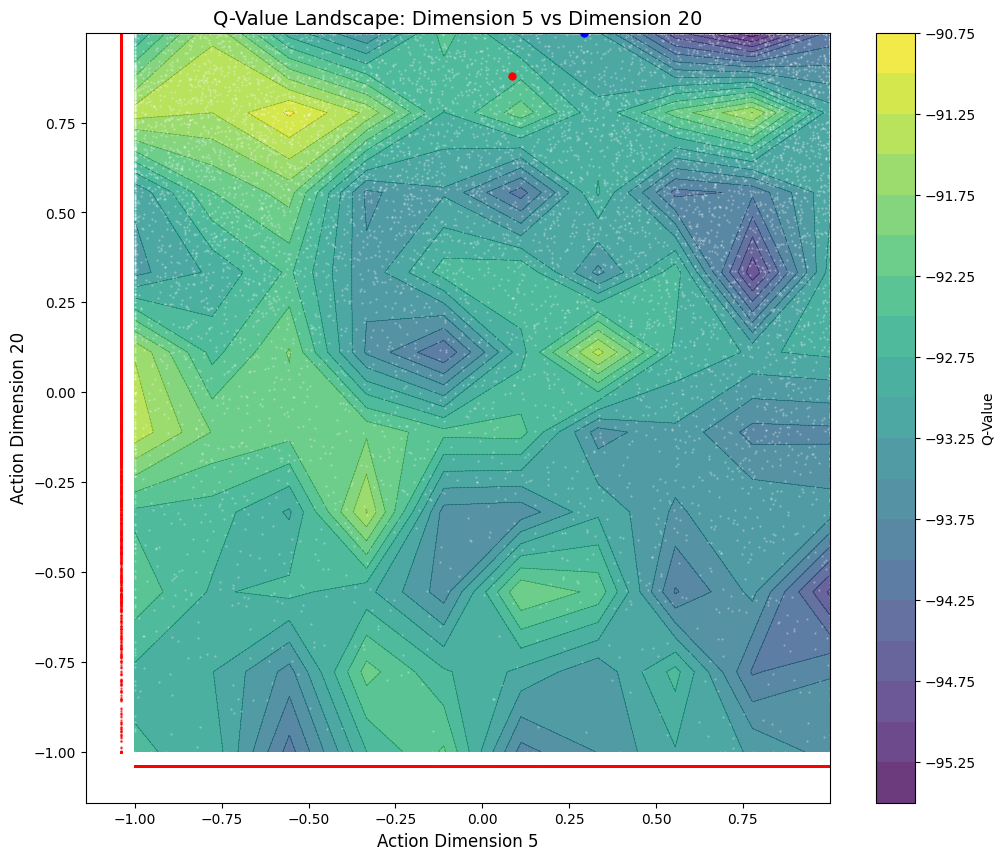

In [209]:
ob = target_states[target_idx]

# fql_pred = fql_agent.sample_actions(ob)
fql_pred_reg = fql_reg_actor_fn(ob).clip(-1, 1) # Run actor

q_vals = critic_fn(fql_reg_agent, target_states, actions)
dataset_q_val = fql_reg_agent.network.select('critic')(ob, fql_pred_reg)

_, rets = find_highest_avg_score_dimension(actions, q_vals)
sorted_dims = sorted(rets.keys(), key=lambda x: rets[x], reverse=True)

action_dim1, action_dim2 = sorted_dims[0], sorted_dims[1]

# dimension where the dataset_action and predicted action are the most different by l2 distance
print(f"distances: {dataset_action - fql_pred_reg}")
print(f"max distance: {np.max(np.abs(dataset_action - fql_pred_reg))}")
print(f"mean distance: {np.mean(np.abs(dataset_action - fql_pred_reg))}")
print(f"min distance: {np.min(np.abs(dataset_action - fql_pred_reg))}")
dist_sorted_dims = np.argsort(np.abs(dataset_action - fql_pred_reg))[::-1]
action_dim1, action_dim2 = dist_sorted_dims[2], dist_sorted_dims[3]
print(dist_sorted_dims)

action_dim1, action_dim2 = 5, 20

ax = plot_q_value_landscape_2d(
    np.concatenate([actions, fql_pred_reg.reshape(1,-1)], axis=0), 
    np.concatenate([q_vals, np.array([dataset_q_val.min()])]), 
    dim_x=action_dim1, dim_y=action_dim2, num_bins=10)
if ax is None:
    ax = plt.gca()
ax.plot(fql_pred_reg[action_dim1], fql_pred_reg[action_dim2], 'ro', markersize=5)
ax.plot(dataset_action[action_dim1], dataset_action[action_dim2], 'bo', markersize=5)

100%|██████████| 40/40 [00:02<00:00, 13.45it/s]
/tmp/ipykernel_3696325/961229665.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('action_bin').agg(
/tmp/ipykernel_3696325/961229665.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('action_bin').agg(
/tmp/ipykernel_3696325/961229665.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = df.groupby('a

distances: [ 0.15719932 -0.01517701 -0.52497923  0.21461958  0.04836214  0.42183438
  0.00635409 -0.04643149  0.14265302 -0.0160923  -0.07964051  0.02076066
  0.63567996  0.12558484 -0.2236771  -0.4803335   0.54980206  0.16995847
  0.82209325 -0.22449133  0.209692  ]
max distance: 0.8220932483673096
mean distance: 0.2445436269044876
min distance: 0.006354093551635742
[18 12 16  2 15  5 19 14  3 20 17  0  8 13 10  4  7 11  9  1  6]
Q-value range: -96.9806 to -87.7743


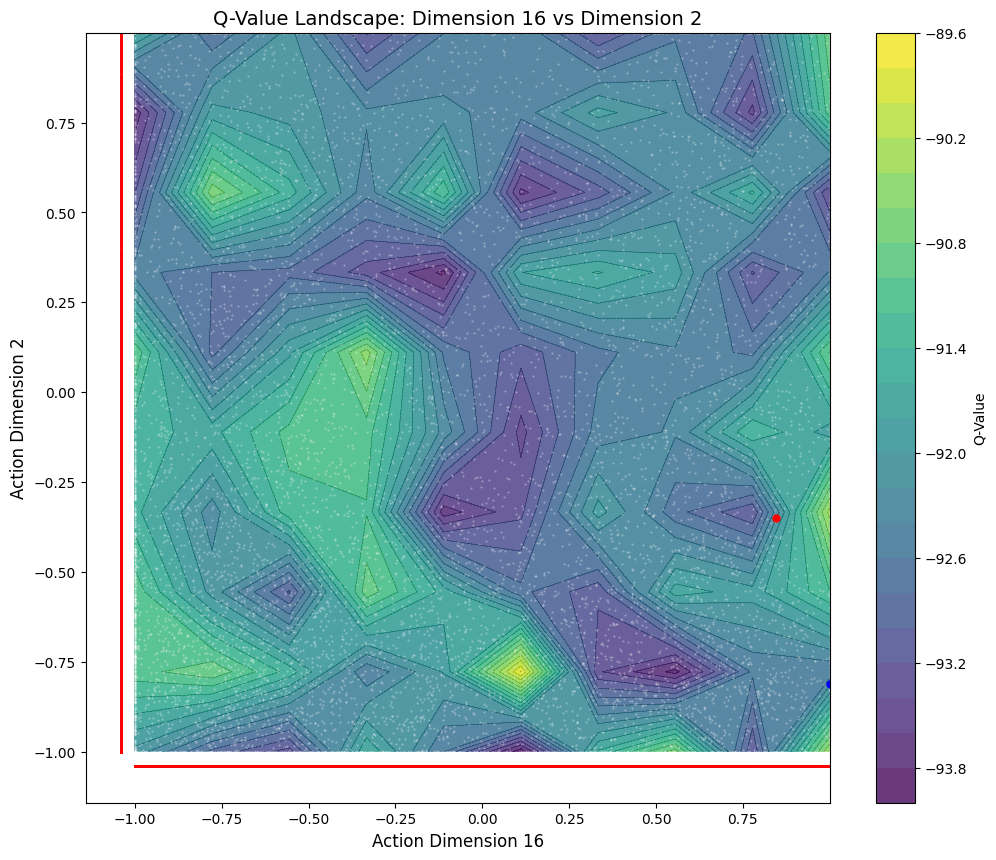

In [210]:
ob = target_states[target_idx]

# fql_pred = fql_agent.sample_actions(ob)
fql_pred = fql_actor_fn(ob) # Run actor
q_vals = critic_fn(fql_agent, target_states, actions)
dataset_q_val = fql_agent.network.select('critic')(ob, fql_pred)

_, rets = find_highest_avg_score_dimension(actions, q_vals)
sorted_dims = sorted(rets.keys(), key=lambda x: rets[x], reverse=True)

action_dim1, action_dim2 = sorted_dims[0], sorted_dims[1]
action_dim1, action_dim2 = 0, 1

print(f"distances: {dataset_action - fql_pred}")
print(f"max distance: {np.max(np.abs(dataset_action - fql_pred))}")
print(f"mean distance: {np.mean(np.abs(dataset_action - fql_pred))}")
print(f"min distance: {np.min(np.abs(dataset_action - fql_pred))}")
dist_sorted_dims = np.argsort(np.abs(dataset_action - fql_pred))[::-1]
action_dim1, action_dim2 = dist_sorted_dims[2], dist_sorted_dims[3]
print(dist_sorted_dims)

ax = plot_q_value_landscape_2d(
    np.concatenate([actions, fql_pred.reshape(1,-1)], axis=0), 
    np.concatenate([q_vals, np.array([dataset_q_val.min()])]), 
    dim_x=action_dim1, dim_y=action_dim2, num_bins=10)
if ax is None:
    ax = plt.gca()
ax.plot(fql_pred_reg[action_dim1], fql_pred_reg[action_dim2], 'ro', markersize=5)
ax.plot(dataset_action[action_dim1], dataset_action[action_dim2], 'bo', markersize=5)